# Phase 3 — Continuous Decoding · DANDI_000140 (Local Zarr)

Predicts hand velocity (vx, vy) from binned spike counts using Ridge, Wiener filter,
and Kalman filter on a single Jenkins session from DANDI_000140.
Compares raw electrode features against PCA(20)-reduced features for Ridge and Wiener.

**Runs without S3 credentials** — data loaded from local Zarr on disk.

> **Note on velocity:** The S3 combined dataset has a known vx == vy duplication bug for
> DANDI_000140. The **local** Zarr produced by `DANDI_000140_Utils` reads `hand_vel`
> directly from the NWB file and is **not** affected — confirmed: `np.allclose(vx, vy) → False`.

| Cell | Content |
|------|---------|
| 1 | Imports + path constants |
| 2 | Load session from local Zarr (no S3) |
| 3 | Feature extraction: binned spikes (X), mean-pooled velocity (y), inter-trial filter |
| 4 | Temporal 80/20 train/test split (`shuffle=False`) |
| 5 | Ridge (raw) |
| 6 | Ridge + PCA(20) |
| 7 | Wiener filter (raw) |
| 8 | Wiener filter + PCA(20) |
| 9 | Kalman filter (raw) |
| 10 | Summary table |
| 11 | Predicted vs actual velocity plots |

In [1]:
from pathlib import Path
import sys
_repo_root = Path.cwd() if (Path.cwd() / "decoding").is_dir() else Path.cwd().parent
if str(_repo_root) not in sys.path:
    sys.path.insert(0, str(_repo_root))

import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from bci_decoding_dataset import DatasetLoader

from decoding import (
    compute_bin_phases,
    compute_binned_counts,
    DimReducer,
    KalmanFilterDecoder,
    RidgeDecoder,
    WienerFilterDecoder,
    WienerRidgeDecoder,
)

sns.set_theme(style="whitegrid", font_scale=1.1)
warnings.filterwarnings("ignore", category=PendingDeprecationWarning)

# ── Hardcoded paths (only values that may need changing) ─────────────────────
LOCAL_ZARR_PATH = "C:/Git_practica/bci-decoding-dataset/000140/DANDI_000140_processed.zarr"
SESSION_ID      = "Jenkins_20090928"

# ── Pipeline parameters ──────────────────────────────────────────────────────
BIN_SIZE_MS    = 50     # spike binning window (ms)
N_LAGS         = 5      # Wiener filter: past bins appended as features
TRAIN_FRAC     = 0.80   # temporal train/test split
PCA_COMPONENTS = 20     # components for DimReducer PCA
PLOT_BINS      = 200    # bins shown in trace plots

print("✓ All imports successful")
print(f"Local Zarr : {LOCAL_ZARR_PATH}")
print(f"Session    : {SESSION_ID}")
print(f"bin_size_ms: {BIN_SIZE_MS}  |  n_lags: {N_LAGS}  |  pca_components: {PCA_COMPONENTS}")

✓ All imports successful
Local Zarr : C:/Git_practica/bci-decoding-dataset/000140/DANDI_000140_processed.zarr
Session    : Jenkins_20090928
bin_size_ms: 50  |  n_lags: 5  |  pca_components: 20


## Load Session

The local Zarr stores the raw NWB file structure and is read by `DatasetLoader`
with `aws_store=False`. No S3 credentials are required.

In [3]:
loader_local = DatasetLoader(
    aws_store=False,
    combined_dataset_path=LOCAL_ZARR_PATH,
)
ds = loader_local.get_processed_data_from_session(SESSION_ID)

print(f"Session:        {SESSION_ID}")
print(f"Subject:        {ds.attrs.get('subject_id', 'unknown')}")
print(f"Task:           {ds.attrs.get('task_type', 'unknown')}")
print(f"Sampling rate:  {ds.attrs.get('sampling_rate', 'unknown')} Hz")
print(f"Spikes shape:   {ds['spikes'].shape}  (n_electrodes \u00d7 n_time)")
print(f"Velocity shape: {ds['velocity'].shape}")
print(f"n_trials:       {ds.attrs.get('n_trials', 'unknown')}")
print("\u2713 Session loaded from local Zarr (no S3 required)")

Reading data from session: Jenkins_20090928
Session:        Jenkins_20090928
Subject:        Jenkins
Task:           center_out_maze
Sampling rate:  1000.0 Hz
Spikes shape:   (107, 293666)  (n_electrodes × n_time)
Velocity shape: (293666, 2)
n_trials:       100
✓ Session loaded from local Zarr (no S3 required)


## Feature Extraction

`compute_binned_counts` sums spikes in non-overlapping 50 ms windows → `(n_bins, n_electrodes)`.
Velocity is mean-pooled over the same windows.
Inter-trial bins (`trial_phase == 0`) are removed before decoding.

In [4]:
X_all      = compute_binned_counts(ds, bin_size_ms=BIN_SIZE_MS)   # (n_bins, n_el)
n_bins     = X_all.shape[0]
bin_phases = compute_bin_phases(ds, bin_size_ms=BIN_SIZE_MS)       # (n_bins,)

velocity  = ds["velocity"].values          # (n_time, 2), float32
n_trimmed = n_bins * BIN_SIZE_MS
y_all = velocity[:n_trimmed].reshape(n_bins, BIN_SIZE_MS, 2).mean(axis=1)  # (n_bins, 2)

active_mask = bin_phases > 0
X = X_all[active_mask]
y = y_all[active_mask]

print(f"All bins:    X={X_all.shape}   y={y_all.shape}")
print(f"Active bins: X={X.shape}   y={y.shape}")
print(f"Dropped {(~active_mask).sum()} inter-trial bins ({(~active_mask).mean()*100:.1f}%)")
print(f"vx range: [{y[:, 0].min():.3f}, {y[:, 0].max():.3f}]")
print(f"vy range: [{y[:, 1].min():.3f}, {y[:, 1].max():.3f}]")
assert not np.allclose(y[:, 0], y[:, 1]), "vx == vy bug detected \u2014 local Zarr may be wrong"
print("\u2713 vx \u2260 vy confirmed (local Zarr reads hand_vel directly from NWB)")

All bins:    X=(5873, 107)   y=(5873, 2)
Active bins: X=(5754, 107)   y=(5754, 2)
Dropped 119 inter-trial bins (2.0%)
vx range: [-0.963, 0.955]
vy range: [-0.896, 0.949]
✓ vx ≠ vy confirmed (local Zarr reads hand_vel directly from NWB)


## Train/Test Split

Single temporal cutpoint at 80%: first 80% of active bins → train, last 20% → test.
`shuffle=False` is mandatory for time-series data.

In [5]:
split = int(len(X) * TRAIN_FRAC)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"Train: {X_train.shape[0]} bins  ({X_train.shape[0] * BIN_SIZE_MS / 1000:.1f} s)")
print(f"Test:  {X_test.shape[0]} bins   ({X_test.shape[0] * BIN_SIZE_MS / 1000:.1f} s)")

Train: 4603 bins  (230.2 s)
Test:  1151 bins   (57.5 s)


## Ridge 

Baseline: Ridge regression on all `n_electrodes` binned spike counts.

In [17]:
ridge_raw = RidgeDecoder(alpha=1) #No cambia casi nada, 140 solo tiene 100 trials. No es por overfitting?
ridge_raw.fit(X_train, y_train)

r2_ridge_raw     = ridge_raw.score(X_test, y_test)   # shape (2,)
y_pred_ridge_raw = ridge_raw.predict(X_test)

print(f"Ridge (raw)  R\u00b2 vx = {r2_ridge_raw[0]:.4f}")
print(f"Ridge (raw)  R\u00b2 vy = {r2_ridge_raw[1]:.4f}")

Ridge (raw)  R² vx = 0.0701
Ridge (raw)  R² vy = 0.1412


## Ridge PCA

`DimReducer` with `method='pca'` is fitted on `X_train` only, then applied to both splits.
PCA captures the dominant variance directions and removes noise dimensions,
which may improve generalisation when n_electrodes >> n_useful_dimensions.

In [ ]:
reducer_r = DimReducer(method="pca", n_components=PCA_COMPONENTS)
X_train_pca_r = reducer_r.fit_transform(X_train)   # (n_train, n_comp)
X_test_pca_r  = reducer_r.transform(X_test)         # (n_test,  n_comp)

ridge_pca = RidgeDecoder(alpha=1.0)
ridge_pca.fit(X_train_pca_r, y_train)

r2_ridge_pca     = ridge_pca.score(X_test_pca_r, y_test)   # shape (2,)
y_pred_ridge_pca = ridge_pca.predict(X_test_pca_r)

n_comp_r = reducer_r.n_components_actual_
print(f"PCA: {X_train.shape[1]} electrodes \u2192 {n_comp_r} components")
print(f"Ridge (PCA)  R\u00b2 vx = {r2_ridge_pca[0]:.4f}")
print(f"Ridge (PCA)  R\u00b2 vy = {r2_ridge_pca[1]:.4f}")
#Se descartaron 87 componentes, antes que eran útiles pq el R2 bajó. Info útil pero poca varianza.

PCA: 107 electrodes → 20 components
Ridge (PCA)  R² vx = 0.0304
Ridge (PCA)  R² vy = 0.0718


## Wiener Filter 

Appends `n_lags` previous bins as features, giving `n_lags × 50 ms` of neural history.
The lag matrix trims `n_lags` rows from the start; `y_test_wiener` is trimmed to match.

In [ ]:
wiener_raw = WienerFilterDecoder(n_lags=N_LAGS)
wiener_raw.fit(X_train, y_train)

r2_wiener_raw     = wiener_raw.score(X_test, y_test)   # shape (2,)
y_pred_wiener_raw = wiener_raw.predict(X_test)          # shape (n_test - N_LAGS, 2)
y_test_wiener     = y_test[N_LAGS:]                     # aligned ground truth for both wiener variants

print(f"Wiener (raw) R\u00b2 vx = {r2_wiener_raw[0]:.4f}  ({N_LAGS} lags = {N_LAGS * BIN_SIZE_MS} ms history)")
print(f"Wiener (raw) R\u00b2 vy = {r2_wiener_raw[1]:.4f}")
#5 lags, 50 ms bin size, 250 ms history
#Temporal info es muy importante, neurons spike some time before movement.

Wiener (raw) R² vx = 0.4200  (5 lags = 250 ms history)
Wiener (raw) R² vy = 0.3189


## Wiener Filter PCA

Same PCA preprocessing as Ridge + PCA: reduce to 20 components before building the lag matrix.

In [9]:
reducer_w = DimReducer(method="pca", n_components=PCA_COMPONENTS)
X_train_pca_w = reducer_w.fit_transform(X_train)
X_test_pca_w  = reducer_w.transform(X_test)

wiener_pca = WienerFilterDecoder(n_lags=N_LAGS)
wiener_pca.fit(X_train_pca_w, y_train)

r2_wiener_pca     = wiener_pca.score(X_test_pca_w, y_test)   # shape (2,)
y_pred_wiener_pca = wiener_pca.predict(X_test_pca_w)          # shape (n_test - N_LAGS, 2)

n_comp_w = reducer_w.n_components_actual_
print(f"PCA: {X_train.shape[1]} electrodes \u2192 {n_comp_w} components")
print(f"Wiener (PCA) R\u00b2 vx = {r2_wiener_pca[0]:.4f}")
print(f"Wiener (PCA) R\u00b2 vy = {r2_wiener_pca[1]:.4f}")

PCA: 107 electrodes → 20 components
Wiener (PCA) R² vx = 0.3233
Wiener (PCA) R² vy = 0.2584


## Wiener-Ridge

Combines temporal lags (Wiener filter) with L2 regularization (Ridge regression).
The alpha sweep checks whether regularization strength matters beyond the
unregularized Wiener filter baseline.

In [ ]:
wiener_ridge = WienerRidgeDecoder(n_lags=N_LAGS, alpha=1.0)
wiener_ridge.fit(X_train, y_train)

r2_wiener_ridge     = wiener_ridge.score(X_test, y_test)   # shape (2,)
y_pred_wiener_ridge = wiener_ridge.predict(X_test)          # shape (n_test - N_LAGS, 2)

print(f"WienerRidge (raw, alpha=1.0)  R² vx = {r2_wiener_ridge[0]:.4f}  ({N_LAGS} lags = {N_LAGS * BIN_SIZE_MS} ms history)")
print(f"WienerRidge (raw, alpha=1.0)  R² vy = {r2_wiener_ridge[1]:.4f}")

print("\n─── Alpha sweep ───")
for alpha in [0.01, 0.1, 1.0, 10.0, 100.0]:
    _wr = WienerRidgeDecoder(n_lags=N_LAGS, alpha=alpha)
    _wr.fit(X_train, y_train)
    _r2 = _wr.score(X_test, y_test)
    print(f"  alpha={alpha:7.2f}  R² vx={_r2[0]:.4f}  R² vy={_r2[1]:.4f}")

    #alpha 100 (acá si mejora) acá hay historial, features más correlated? distribuye peso en los que 
    # estan correlacionados y no solo en uno  

WienerRidge (raw, alpha=1.0)  R² vx = 0.4201  (5 lags = 250 ms history)
WienerRidge (raw, alpha=1.0)  R² vy = 0.3189

─── Alpha sweep ───
  alpha=   0.01  R² vx=0.4200  R² vy=0.3189
  alpha=   0.10  R² vx=0.4200  R² vy=0.3189
  alpha=   1.00  R² vx=0.4201  R² vy=0.3189
  alpha=  10.00  R² vx=0.4207  R² vy=0.3196
  alpha= 100.00  R² vx=0.4267  R² vy=0.3260


## Kalman Filter 

Probabilistic state-space decoder. `predict(X_test, y_test)` seeds from `y_test[0]`
then propagates forward using only neural observations.

In [11]:
kalman = KalmanFilterDecoder(C=1, lag=0)
kalman.fit(X_train, y_train)

r2_kalman     = kalman.score(X_test, y_test)          # shape (2,)
y_pred_kalman = kalman.predict(X_test, y_test)

print(f"Kalman (raw) R\u00b2 vx = {r2_kalman[0]:.4f}")
print(f"Kalman (raw) R\u00b2 vy = {r2_kalman[1]:.4f}")




Kalman (raw) R² vx = -0.0690
Kalman (raw) R² vy = 0.0319


## Summary

In [12]:
summary = pd.DataFrame({
    "Decoder": ["Ridge",          "Ridge",                  "Wiener",         "Wiener",                  "WienerRidge", "Kalman"],
    "Input":   ["Raw",            f"PCA({PCA_COMPONENTS})", "Raw",            f"PCA({PCA_COMPONENTS})",  "Raw",         "Raw"],
    "R² vx": [
        f"{r2_ridge_raw[0]:.4f}",
        f"{r2_ridge_pca[0]:.4f}",
        f"{r2_wiener_raw[0]:.4f}",
        f"{r2_wiener_pca[0]:.4f}",
        f"{r2_wiener_ridge[0]:.4f}",
        f"{r2_kalman[0]:.4f}",
    ],
    "R² vy": [
        f"{r2_ridge_raw[1]:.4f}",
        f"{r2_ridge_pca[1]:.4f}",
        f"{r2_wiener_raw[1]:.4f}",
        f"{r2_wiener_pca[1]:.4f}",
        f"{r2_wiener_ridge[1]:.4f}",
        f"{r2_kalman[1]:.4f}",
    ],
})
display(summary)

,Decoder,Input,R² vx,R² vy
0,Ridge,Raw,0.0701,0.1412
1,Ridge,PCA(20),0.0304,0.0718
2,Wiener,Raw,0.4200,0.3189
3,Wiener,PCA(20),0.3233,0.2584
4,WienerRidge,Raw,0.4201,0.3189
5,Kalman,Raw,-0.0690,0.0319


## Visualization — Predicted vs Actual Velocity

Five decoder configurations, two velocity components each (5 rows × 2 columns).
First `PLOT_BINS` test bins shown.

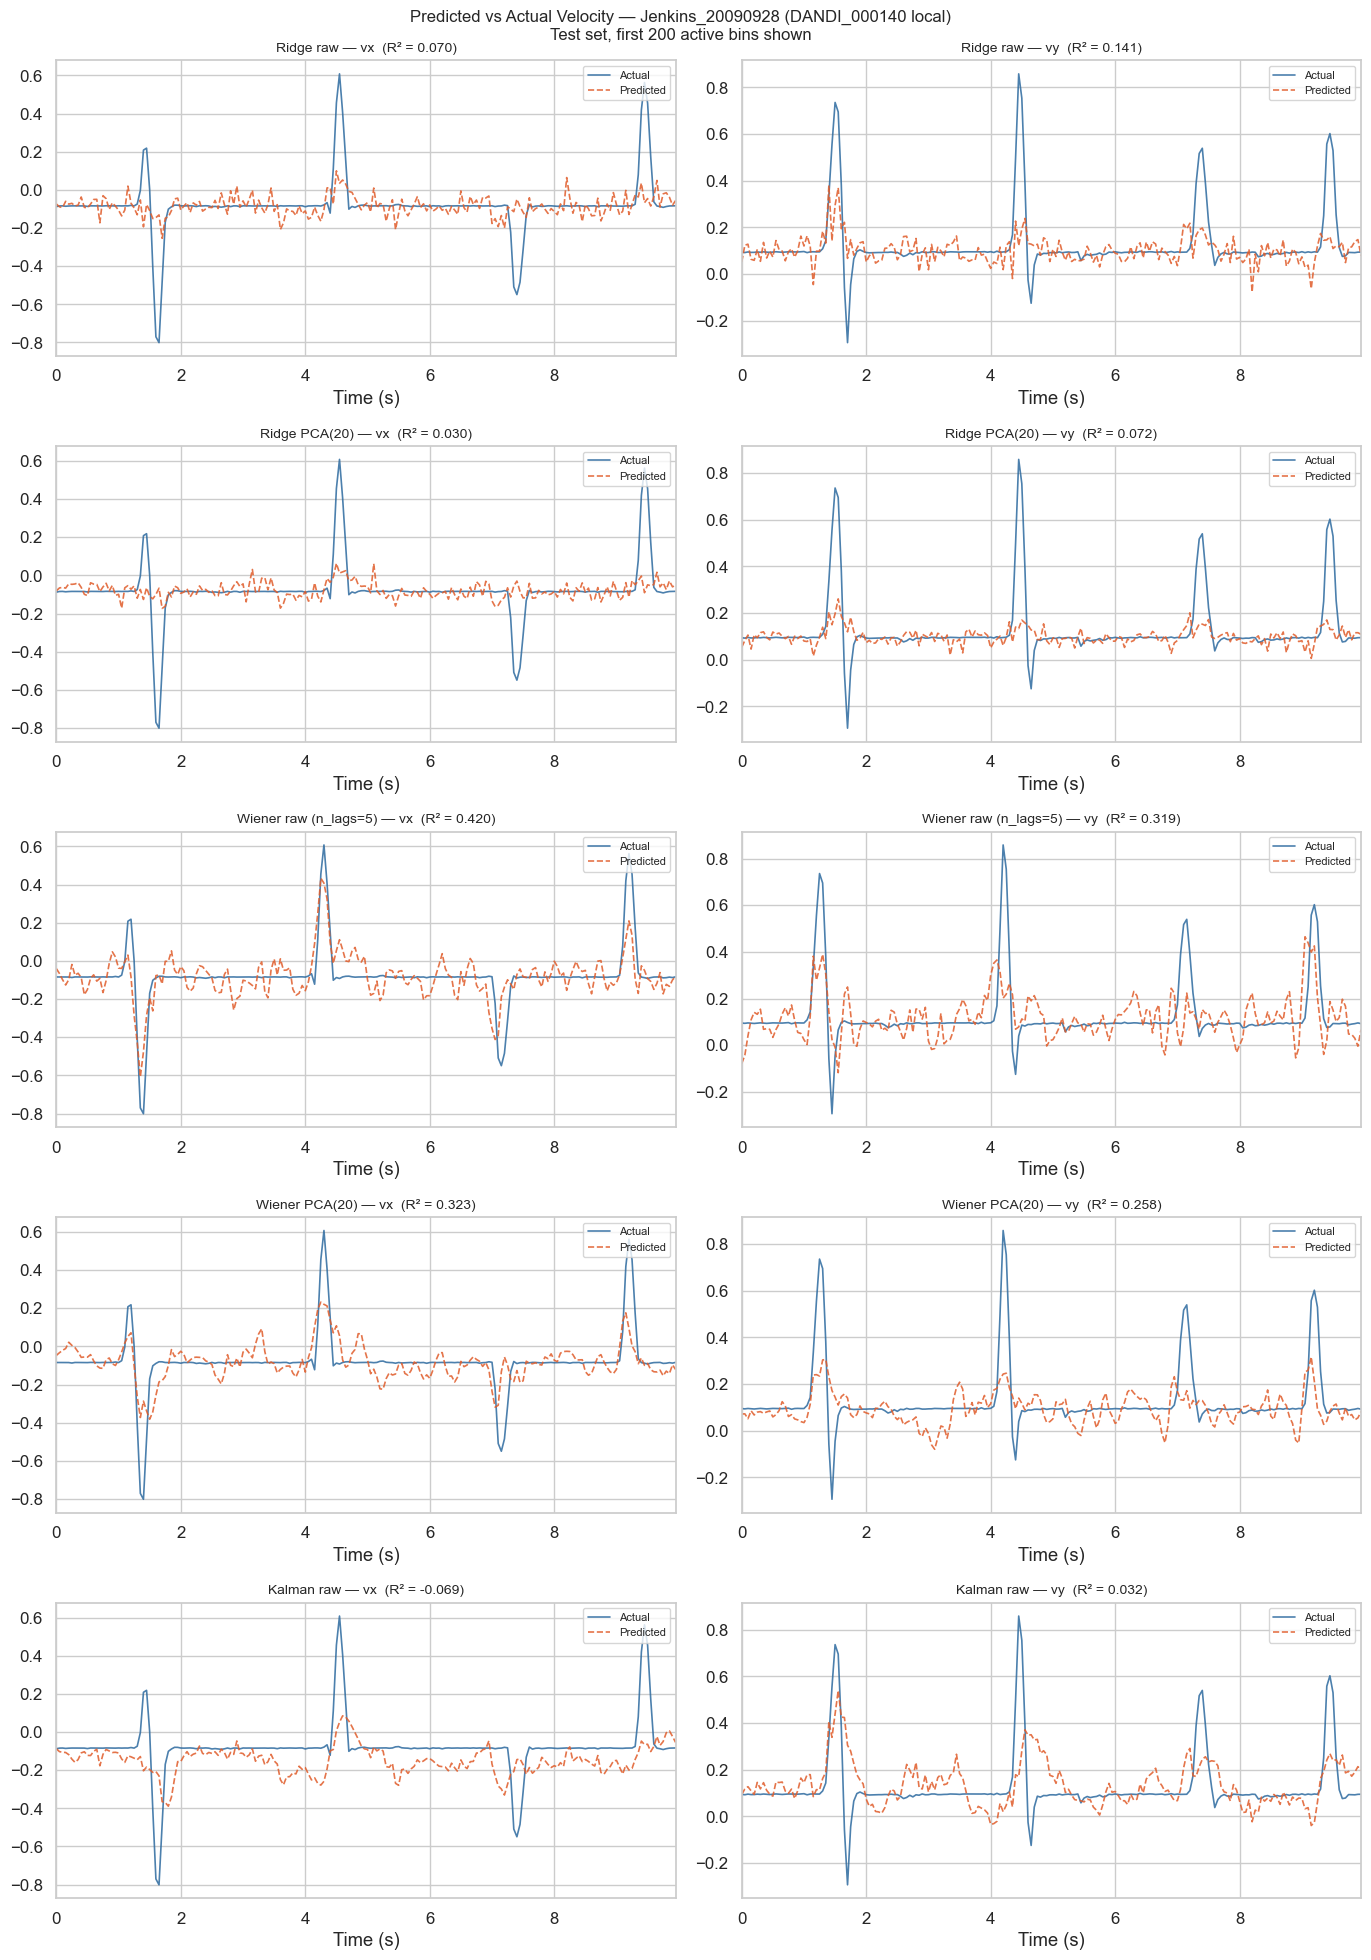

Saved: 02_ContinuousDecoding_DANDI140_velocity.png


In [13]:
pb_r = min(PLOT_BINS, len(y_test))
pb_w = min(PLOT_BINS, len(y_test_wiener))
t_r  = np.arange(pb_r) * BIN_SIZE_MS / 1000
t_w  = np.arange(pb_w) * BIN_SIZE_MS / 1000

def _plot(ax, t, y_true, y_pred, r2_val, title):
    ax.plot(t, y_true, color="#2d6a9f", lw=1.2, label="Actual",    alpha=0.85)
    ax.plot(t, y_pred, color="#e05c2a", lw=1.2, label="Predicted", ls="--", alpha=0.85)
    ax.set_title(f"{title}  (R\u00b2 = {r2_val:.3f})", fontsize=10)
    ax.set_xlabel("Time (s)")
    ax.legend(fontsize=8, loc="upper right")
    ax.set_xlim(t[0], t[-1])

fig, axes = plt.subplots(5, 2, figsize=(14, 20))
fig.suptitle(
    f"Predicted vs Actual Velocity \u2014 {SESSION_ID} (DANDI_000140 local)\n"
    f"Test set, first {PLOT_BINS} active bins shown",
    fontsize=12,
)

_plot(axes[0, 0], t_r, y_test[:pb_r, 0], y_pred_ridge_raw[:pb_r, 0], r2_ridge_raw[0], "Ridge raw \u2014 vx")
_plot(axes[0, 1], t_r, y_test[:pb_r, 1], y_pred_ridge_raw[:pb_r, 1], r2_ridge_raw[1], "Ridge raw \u2014 vy")

_plot(axes[1, 0], t_r, y_test[:pb_r, 0], y_pred_ridge_pca[:pb_r, 0], r2_ridge_pca[0], f"Ridge PCA({PCA_COMPONENTS}) \u2014 vx")
_plot(axes[1, 1], t_r, y_test[:pb_r, 1], y_pred_ridge_pca[:pb_r, 1], r2_ridge_pca[1], f"Ridge PCA({PCA_COMPONENTS}) \u2014 vy")

_plot(axes[2, 0], t_w, y_test_wiener[:pb_w, 0], y_pred_wiener_raw[:pb_w, 0], r2_wiener_raw[0], f"Wiener raw (n_lags={N_LAGS}) \u2014 vx")
_plot(axes[2, 1], t_w, y_test_wiener[:pb_w, 1], y_pred_wiener_raw[:pb_w, 1], r2_wiener_raw[1], f"Wiener raw (n_lags={N_LAGS}) \u2014 vy")

_plot(axes[3, 0], t_w, y_test_wiener[:pb_w, 0], y_pred_wiener_pca[:pb_w, 0], r2_wiener_pca[0], f"Wiener PCA({PCA_COMPONENTS}) \u2014 vx")
_plot(axes[3, 1], t_w, y_test_wiener[:pb_w, 1], y_pred_wiener_pca[:pb_w, 1], r2_wiener_pca[1], f"Wiener PCA({PCA_COMPONENTS}) \u2014 vy")

_plot(axes[4, 0], t_r, y_test[:pb_r, 0], y_pred_kalman[:pb_r, 0], r2_kalman[0], "Kalman raw \u2014 vx")
_plot(axes[4, 1], t_r, y_test[:pb_r, 1], y_pred_kalman[:pb_r, 1], r2_kalman[1], "Kalman raw \u2014 vy")

plt.tight_layout()
plt.savefig("02_ContinuousDecoding_DANDI140_velocity.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: 02_ContinuousDecoding_DANDI140_velocity.png")